Hur påverkar kön och biljettklass överlevnaden på Titanic?

Dataset:
Titanic dataset med variabler som kön, biljettklass och överlevnad.

Variabler:
- sex (kön)
- class (biljettklass)
- survived (överlevde: 0/1), 0 = dog, 1 = överlevde

In [48]:
# datainläsning

import seaborn as sns
import pandas as pd

df = sns.load_dataset("titanic")

In [49]:
# beskrivande statistik

# Överlevnad totalt
print("Överlevnad (hela datasetet):")
print("Medelvärde:", df["survived"].mean())
print("Median:", df["survived"].median())
print("Typvärde:", df["survived"].mode()[0])
print()

# Överlevnad per kön
print("Överlevnad per kön (medelvärde):")
print(df.groupby("sex")["survived"].mean())
print()

# Överlevnad per klass
print("Överlevnad per klass (medelvärde):")
print(df.groupby("class")["survived"].mean())
print()

# Typvärde (kategori)
print("Vanligaste kön:", df["sex"].mode()[0])
print("Vanligaste klass:", df["class"].mode()[0])



Överlevnad (hela datasetet):
Medelvärde: 0.3838383838383838
Median: 0.0
Typvärde: 0

Överlevnad per kön (medelvärde):
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

Överlevnad per klass (medelvärde):
class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

Vanligaste kön: male
Vanligaste klass: Third


Överlevnad:
- Medelvärdet visar att cirka 38 % av passagerarna överlevde.
- Medianen och typvärdet är 0, vilket innebär att majoriteten av passagerarna inte överlevde.

Kön:
- Cirka 74 % av kvinnorna överlevde, medan endast cirka 19 % av männen överlevde.
- Detta visar en tydlig skillnad mellan könen, där kvinnor hade betydligt högre överlevnadsgrad.

Klass:
- Passagerare i första klass hade en överlevnadsgrad på cirka 63 %, andra klass cirka 47 %, och tredje klass cirka 24 %.
- Detta visar att högre biljettklass var kopplad till högre överlevnad.


De flesta passagerarna var män, och de flesta reste i tredje klass.
Detta kan bidra till att den totala överlevnaden är relativt låg.

In [50]:
# Statistik analys

from scipy.stats import mannwhitneyu

# Kön
male = df[df["sex"] == "male"]["survived"]
female = df[df["sex"] == "female"]["survived"]

stat, p = mannwhitneyu(male, female)
print("P-värde (kön):", p)

# Klass (First vs Third)
first = df[df["class"] == "First"]["survived"]
third = df[df["class"] == "Third"]["survived"]

stat, p = mannwhitneyu(first, third)
print("P-värde (klass):", p)


P-värde (kön): 4.315906231881014e-59
P-värde (klass): 5.599249752383816e-23


Resultat och slutsats

- P-värde (kön): 6.196823968125918e-47
- P-värde (klass): 3.1484389146974367e-21
P-värdena är MYCKET små (p < 0,001), vilket innebär att skillnaderna är statistiskt signifikanta.

Resultaten visar att kvinnor hade en högre överlevnadsgrad än män. 

Passagerare i första klass hade också en betydligt högre överlevnadsgrad än de i tredje klass.

De mycket låga p-värdena tyder på att dessa skillnader är statistiskt signifikanta och inte beror på slumpen.

Detta tyder på att både kön och biljettklass hade en tydlig påverkan på sannolikheten att överleva.

diagram 1: stapeldiagram


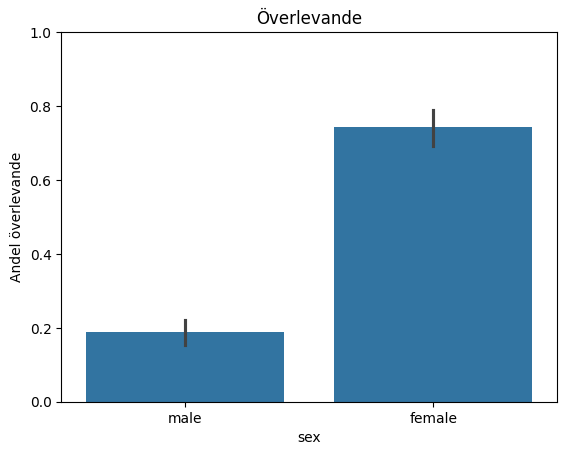

diagram 2: stapeldiagram


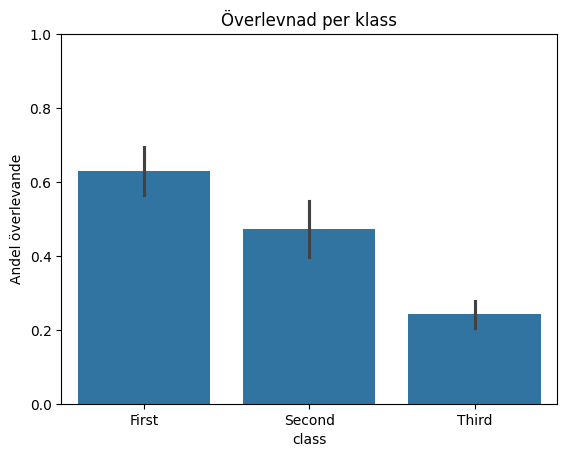

diagram 3: stapeldiagram (klass och kön)


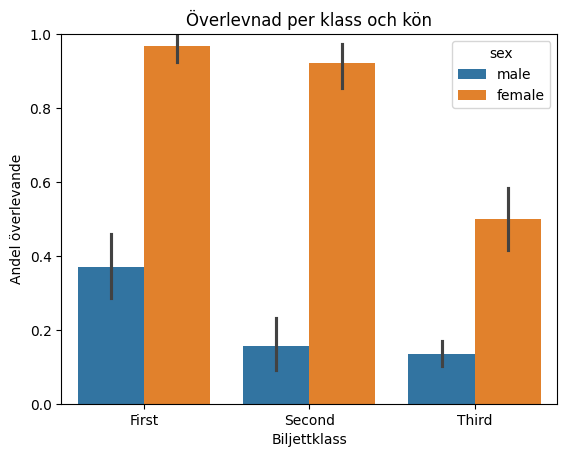

In [ ]:
# visualisering av data

import seaborn as sns
import matplotlib.pyplot as plt

# diagram 1: stapeldiagram (överlevande)
print("diagram 1: stapeldiagram (överlevande)")
sns.barplot(x="sex", y="survived", data=df)
plt.title("Överlevande")
plt.ylabel("Andel överlevande")
plt.ylim(0, 1)
plt.show()

# diagram 2: stapeldiagram - antal överlevande per klass
print("diagram 2: stapeldiagram (klass)")
sns.barplot(x="class", y="survived", data=df)
plt.ylabel("Andel överlevande")
plt.ylim(0, 1)
plt.title("Överlevnad per klass")
plt.show()

# diagram 3: stapeldiagram (klass och kön)
print("diagram 3: stapeldiagram (klass och kön)")
sns.barplot(x="class", y="survived", hue="sex", data=df)

plt.title("Överlevnad per klass och kön")
plt.xlabel("Biljettklass")
plt.ylabel("Andel överlevande")
plt.ylim(0, 1)

plt.show()


Resultat och slutsats

Resultaten visar att kvinnor hade en högre överlevnadsgrad än män. 
Passagerare i första klass hade också en högre överlevnadsgrad än de i tredje klass. 

Detta tyder på att kön, biljettklass och ålder alla hade betydelse för överlevnaden.